# 04 — Avaliação, Métricas e Interpretação

**Grupo 50 • Tech Challenge — Fase 2**

Este notebook avalia os três modelos treinados na etapa 03, utilizando a mesma metodologia de divisão por perfil cadastral e o mesmo pré-processamento ajustado exclusivamente no conjunto de treinamento.

**Objetivo:** responder aos requisitos de avaliação do projeto: comparar métricas, analisar matriz de confusão e ROC-AUC, interpretar a importância das variáveis, verificar ajuste dos modelos e apresentar implicações e limitações para o negócio.

In [1]:
# Reprodutibilidade
RANDOM_STATE = 42
SPLIT_RANDOM_STATE = 7

In [2]:
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

## 1. Carregamento da base

A entrada desta etapa é exatamente a saída do notebook `02_preprocessamento.ipynb`.

Não são utilizados os dados de histórico de crédito como variáveis preditoras. O histórico foi utilizado anteriormente para construção do `TARGET`.

In [3]:
# Localização robusta do projeto
candidatos = [Path.cwd(), Path.cwd().parent]
ROOT = None

for candidato in candidatos:
    if (candidato / "data" / "processed" / "base_modelagem.csv").exists():
        ROOT = candidato
        break

if ROOT is None:
    raise FileNotFoundError(
        "Não foi encontrada data/processed/base_modelagem.csv. "
        "Execute primeiro o notebook 02_preprocessamento."
    )

PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "docs" / "figuras_avaliacao"
FIG_DIR.mkdir(parents=True, exist_ok=True)

dados = pd.read_csv(PROC / "base_modelagem.csv")

print("Raiz do projeto:", ROOT)
print("Base:", PROC / "base_modelagem.csv")
print("Dimensão:", dados.shape)
print("TARGET nulos:", int(dados["TARGET"].isna().sum()))
print("PROFILE_GROUP nulos:", int(dados["PROFILE_GROUP"].isna().sum()))

Raiz do projeto: c:\projetos\Grupo_50_Tech-Challenge-Fase-2
Base: c:\projetos\Grupo_50_Tech-Challenge-Fase-2\data\processed\base_modelagem.csv
Dimensão: (36457, 22)
TARGET nulos: 0
PROFILE_GROUP nulos: 0


## 2. Preparação das variáveis e grupos

O `PROFILE_GROUP` já existe na base produzida pelo notebook 02 e é usado para diagnóstico. Para reproduzir exatamente a metodologia do notebook 03, o grupo utilizado no `StratifiedGroupKFold` é reconstruído a partir das características cadastrais, excluindo `ID`, `TARGET` e `PROFILE_GROUP`.

**Importante:** `ID`, `DAYS_BIRTH`, `DAYS_EMPLOYED` e `PROFILE_GROUP` não entram como variáveis preditoras.

In [4]:
dados_modelo = dados.copy()

y = dados_modelo["TARGET"].astype(int)

colunas_perfil = [
    c for c in dados_modelo.columns
    if c not in ["ID", "TARGET", "PROFILE_GROUP"]
]

groups = pd.util.hash_pandas_object(
    dados_modelo[colunas_perfil].astype(str),
    index=False,
).astype(str)

colunas_excluir = [
    "TARGET", "PROFILE_GROUP", "ID", "DAYS_BIRTH", "DAYS_EMPLOYED"
]

X = dados_modelo.drop(
    columns=[c for c in colunas_excluir if c in dados_modelo.columns]
).copy()

print("Observações:", len(X))
print("Variáveis antes do encoding:", X.shape[1])
print("Grupos cadastrais:", groups.nunique())
print("Nulos antes do split:", int(X.isna().sum().sum()))

Observações: 36457
Variáveis antes do encoding: 17
Grupos cadastrais: 9728
Nulos antes do split: 17458


## 3. Divisão treino, validação e teste por grupo

A divisão segue a mesma lógica do notebook 03:

- `StratifiedGroupKFold`;
- 7 folds;
- `random_state=7`;
- seleção de dois folds próximos de 15% da base e da prevalência global;
- nenhum grupo cadastral pode aparecer em mais de um conjunto.

O conjunto de teste permanece intocado durante a seleção do hiperparâmetro do KNN.

In [5]:
sgkf = StratifiedGroupKFold(
    n_splits=7,
    shuffle=True,
    random_state=SPLIT_RANDOM_STATE,
)

folds = list(sgkf.split(X, y, groups=groups))

prevalencia_global = y.mean()
avaliacao_folds = []

for fold_id, (_, idx_fold) in enumerate(folds):
    proporcao = len(idx_fold) / len(X)
    prevalencia = y.iloc[idx_fold].mean()
    score = abs(proporcao - 0.15) + abs(prevalencia - prevalencia_global)
    avaliacao_folds.append((fold_id, proporcao, prevalencia, score))

avaliacao_folds_df = pd.DataFrame(
    avaliacao_folds,
    columns=["fold", "proporcao", "prevalencia_mau", "score"],
).sort_values("score")

display(
    avaliacao_folds_df.style.format({
        "proporcao": "{:.2%}",
        "prevalencia_mau": "{:.2%}",
        "score": "{:.5f}",
    })
)

fold_teste = int(avaliacao_folds_df.iloc[0]["fold"])
fold_validacao = int(
    avaliacao_folds_df[
        avaliacao_folds_df["fold"] != fold_teste
    ].sort_values("score").iloc[0]["fold"]
)

idx_teste = folds[fold_teste][1]
idx_validacao = folds[fold_validacao][1]
idx_treino = np.setdiff1d(
    np.arange(len(X)),
    np.concatenate([idx_teste, idx_validacao]),
)

X_train_raw = X.iloc[idx_treino].copy()
y_train = y.iloc[idx_treino].copy()

X_val_raw = X.iloc[idx_validacao].copy()
y_val = y.iloc[idx_validacao].copy()

X_test_raw = X.iloc[idx_teste].copy()
y_test = y.iloc[idx_teste].copy()

print("Fold de teste:", fold_teste)
print("Fold de validação:", fold_validacao)
print("Treino:", X_train_raw.shape, "— maus:", int(y_train.sum()))
print("Validação:", X_val_raw.shape, "— maus:", int(y_val.sum()))
print("Teste:", X_test_raw.shape, "— maus:", int(y_test.sum()))

,fold,proporcao,prevalencia_mau,score
4,4,14.72%,1.70%,0.00284
0,0,14.67%,1.83%,0.00477
3,3,14.46%,1.65%,0.00583
1,1,14.38%,1.74%,0.00662
6,6,14.11%,1.83%,0.01025
5,5,14.17%,1.47%,0.01046
2,2,13.49%,1.61%,0.01596


Fold de teste: 4
Fold de validação: 0
Treino: (25743, 17) — maus: 427
Validação: (5347, 17) — maus: 98
Teste: (5367, 17) — maus: 91


In [6]:
# Verificação explícita de sobreposição de grupos
g_train = set(groups.iloc[idx_treino])
g_val = set(groups.iloc[idx_validacao])
g_test = set(groups.iloc[idx_teste])

print("Grupos em comum treino × validação:", len(g_train & g_val))
print("Grupos em comum treino × teste:", len(g_train & g_test))
print("Grupos em comum validação × teste:", len(g_val & g_test))

Grupos em comum treino × validação: 0
Grupos em comum treino × teste: 0
Grupos em comum validação × teste: 0


## 4. Pré-processamento sem vazamento

O pré-processamento é ajustado **somente no treino**:

- numéricas: imputação pela mediana do treino;
- categóricas: imputação pela moda do treino;
- categóricas: One-Hot Encoding aprendido no treino;
- KNN e Regressão Logística: `MinMaxScaler` ajustado no treino;
- Random Forest: matriz imputada/codificada, sem escalonamento.

Assim, validação e teste não influenciam as estatísticas utilizadas no treinamento.

In [7]:
colunas_categoricas = X_train_raw.select_dtypes(include=["object"]).columns.tolist()
colunas_numericas = X_train_raw.select_dtypes(exclude=["object"]).columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            SimpleImputer(strategy="median"),
            colunas_numericas,
        ),
        (
            "categoricas",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        drop="first",
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                ),
            ]),
            colunas_categoricas,
        ),
    ],
    remainder="drop",
)

X_train_proc = preprocessador.fit_transform(X_train_raw)
X_val_proc = preprocessador.transform(X_val_raw)
X_test_proc = preprocessador.transform(X_test_raw)

nomes_features = preprocessador.get_feature_names_out()

X_train = pd.DataFrame(X_train_proc, index=X_train_raw.index, columns=nomes_features)
X_val = pd.DataFrame(X_val_proc, index=X_val_raw.index, columns=nomes_features)
X_test = pd.DataFrame(X_test_proc, index=X_test_raw.index, columns=nomes_features)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Variáveis após encoding:", X_train.shape[1])
print("Nulos após pré-processamento:", int(X_train.isna().sum().sum()))

Variáveis após encoding: 46
Nulos após pré-processamento: 0


## 5. Seleção do K do KNN

O KNN utiliza o mesmo procedimento da etapa 03: testar `K` de 1 a 10 e selecionar aquele que apresentar o maior **F1 da classe 1 na validação**.

O teste não participa desta escolha.

In [8]:
f1_validacao = []

for k in range(1, 11):
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_scaled, y_train)
    pred_val = modelo.predict(X_val_scaled)
    f1_validacao.append(f1_score(y_val, pred_val, zero_division=0))

knn_resultados = pd.DataFrame({
    "K": range(1, 11),
    "F1_validacao": f1_validacao,
})

melhor_k = int(
    knn_resultados.loc[
        knn_resultados["F1_validacao"].idxmax(), "K"
    ]
)

display(knn_resultados.style.format({"F1_validacao": "{:.4f}"}))
print("Melhor K selecionado na validação:", melhor_k)

,K,F1_validacao
0,1,0.0379
1,2,0.0000
2,3,0.0146
3,4,0.0000
4,5,0.0167
5,6,0.0000
6,7,0.0000
7,8,0.0000
8,9,0.0000
9,10,0.0000


Melhor K selecionado na validação: 1


## 6. Treinamento dos modelos

São avaliados:

1. KNN com o melhor `K`;
2. Regressão Logística com `class_weight="balanced"`;
3. Random Forest com `class_weight="balanced"`.

As configurações são as mesmas utilizadas no notebook 03.

In [9]:
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_train_scaled, y_train)

modelo_logistico = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
modelo_logistico.fit(X_train_scaled, y_train)

modelo_floresta = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_floresta.fit(X_train, y_train)

print("Treinamento concluído.")

Treinamento concluído.


## 7. Métricas no conjunto de teste

A avaliação final considera a classe `TARGET = 1` (mau pagador).

- **Precision:** entre os casos classificados como maus, quantos realmente eram maus.
- **Recall:** entre os maus pagadores reais, quantos foram identificados.
- **F1:** equilíbrio entre Precision e Recall.
- **AUC:** capacidade de ordenar positivos acima de negativos em diferentes limiares.
- **Accuracy:** proporção total de acertos, apresentada apenas como métrica complementar devido ao forte desbalanceamento.

In [10]:
pred_knn = modelo_knn.predict(X_test_scaled)
pred_logistico = modelo_logistico.predict(X_test_scaled)
pred_floresta = modelo_floresta.predict(X_test)

prob_knn = modelo_knn.predict_proba(X_test_scaled)[:, 1]
prob_logistico = modelo_logistico.predict_proba(X_test_scaled)[:, 1]
prob_floresta = modelo_floresta.predict_proba(X_test)[:, 1]

def avaliar_modelo(nome, y_real, y_pred, probabilidade):
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, zero_division=0),
        "Recall": recall_score(y_real, y_pred, zero_division=0),
        "F1": f1_score(y_real, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_real, probabilidade),
    }

resultados_teste = pd.DataFrame([
    avaliar_modelo("KNN", y_test, pred_knn, prob_knn),
    avaliar_modelo("Regressão Logística", y_test, pred_logistico, prob_logistico),
    avaliar_modelo("Random Forest", y_test, pred_floresta, prob_floresta),
]).sort_values("F1", ascending=False).reset_index(drop=True)

display(
    resultados_teste.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}",
    })
)

modelo_final_nome = resultados_teste.iloc[0]["Modelo"]
print("Modelo selecionado pelo maior F1 da classe 1:", modelo_final_nome)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.9493,0.0452,0.0989,0.0621,0.6109
1,Regressão Logística,0.6231,0.0160,0.3516,0.0307,0.5065
2,KNN,0.9650,0.0198,0.0220,0.0208,0.5016


Modelo selecionado pelo maior F1 da classe 1: Random Forest


## 8. Interpretação comparativa

O **F1 da classe 1** é utilizado como critério principal porque o objetivo do projeto é identificar maus pagadores em uma classe minoritária. Accuracy isoladamente pode ser enganosa em uma base com apenas 1,69% de casos positivos.

Também são destacados o modelo de maior Recall, para avaliar a capacidade de capturar maus pagadores, e o modelo de maior AUC, para avaliar a discriminação global.

In [11]:
melhor_f1 = resultados_teste.iloc[0]
melhor_recall = resultados_teste.loc[resultados_teste["Recall"].idxmax()]
melhor_auc = resultados_teste.loc[resultados_teste["AUC"].idxmax()]

print(
    f"Maior F1: {melhor_f1['Modelo']} "
    f"({melhor_f1['F1']:.4f})"
)
print(
    f"Maior Recall: {melhor_recall['Modelo']} "
    f"({melhor_recall['Recall']:.4f})"
)
print(
    f"Maior AUC: {melhor_auc['Modelo']} "
    f"({melhor_auc['AUC']:.4f})"
)

print("\nInterpretação:")
print(
    "O modelo escolhido pelo critério definido é o de maior F1 para a classe 1. "
    "O Recall deve ser observado separadamente porque representa a parcela de maus "
    "pagadores efetivamente identificada."
)

Maior F1: Random Forest (0.0621)
Maior Recall: Regressão Logística (0.3516)
Maior AUC: Random Forest (0.6109)

Interpretação:
O modelo escolhido pelo critério definido é o de maior F1 para a classe 1. O Recall deve ser observado separadamente porque representa a parcela de maus pagadores efetivamente identificada.


## 9. Matriz de confusão do modelo selecionado

A matriz permite distinguir:

- **TN:** bons pagadores corretamente classificados;
- **FP:** bons pagadores classificados como maus;
- **FN:** maus pagadores classificados como bons;
- **TP:** maus pagadores corretamente identificados.

Em crédito, o FN merece atenção especial porque representa um mau pagador que não foi sinalizado pelo modelo.

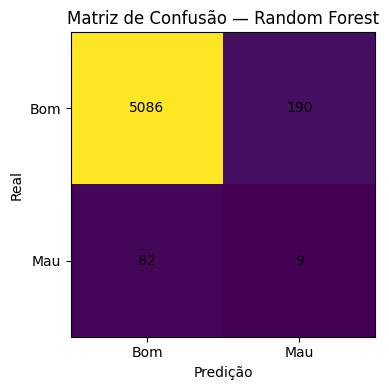

TN = 5086 | FP = 190 | FN = 82 | TP = 9


In [12]:
predicoes = {
    "KNN": pred_knn,
    "Regressão Logística": pred_logistico,
    "Random Forest": pred_floresta,
}

pred_final = predicoes[modelo_final_nome]
cm = confusion_matrix(y_test, pred_final)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
ax.set_title(f"Matriz de Confusão — {modelo_final_nome}")
ax.set_xlabel("Predição")
ax.set_ylabel("Real")
ax.set_xticks([0, 1], ["Bom", "Mau"])
ax.set_yticks([0, 1], ["Bom", "Mau"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_matriz_confusao_modelo_final.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn} | FP = {fp} | FN = {fn} | TP = {tp}")

In [13]:
print(
    f"No teste, havia {int(y_test.sum())} maus pagadores. "
    f"O modelo selecionado identificou {tp} deles (TP) e deixou de identificar "
    f"{fn} (FN)."
)
print(
    f"Entre os {int((y_test == 0).sum())} bons pagadores, "
    f"{fp} foram classificados como maus (FP)."
)

No teste, havia 91 maus pagadores. O modelo selecionado identificou 9 deles (TP) e deixou de identificar 82 (FN).
Entre os 5276 bons pagadores, 190 foram classificados como maus (FP).


## 10. Curvas ROC e AUC

A AUC resume a capacidade discriminativa do modelo considerando diferentes limiares de classificação.

Valores próximos de 0,50 indicam discriminação limitada. Portanto, uma AUC moderadamente acima de 0,50 deve ser interpretada com cautela e não como evidência de um modelo pronto para decisão autônoma.

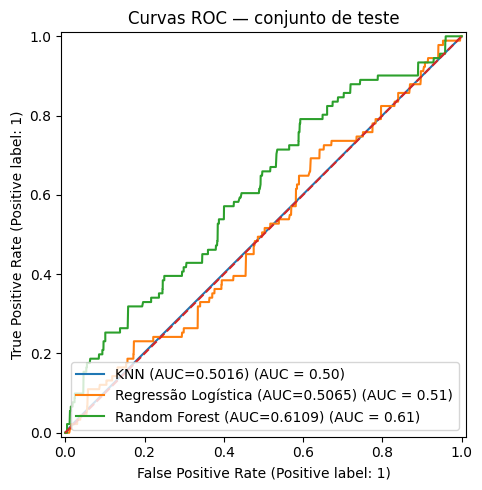

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

for nome, y_pred, prob in [
    ("KNN", pred_knn, prob_knn),
    ("Regressão Logística", pred_logistico, prob_logistico),
    ("Random Forest", pred_floresta, prob_floresta),
]:
    RocCurveDisplay.from_predictions(
        y_test,
        prob,
        name=f"{nome} (AUC={roc_auc_score(y_test, prob):.4f})",
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
ax.set_title("Curvas ROC — conjunto de teste")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_curvas_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Importância das variáveis — Random Forest

A importância do Random Forest é apresentada para interpretação do modelo. O `ID` não participa das variáveis preditoras, portanto não pode aparecer como variável importante.

**Importante:** importância de variável representa contribuição para o comportamento do modelo; não significa causalidade.

,feature,importance
0,numericas__AGE_YEARS,0.1601
1,numericas__EMPLOYED_YEARS,0.1562
2,numericas__AMT_INCOME_TOTAL,0.1316
3,numericas__CNT_FAM_MEMBERS,0.0425
4,categoricas__FLAG_OWN_REALTY_Y,0.0324
5,numericas__CNT_CHILDREN,0.0322
6,categoricas__OCCUPATION_TYPE_Sales staff,0.0267
7,categoricas__FLAG_OWN_CAR_Y,0.0262
8,categoricas__NAME_EDUCATION_TYPE_Secondary / secondary special,0.0241
9,categoricas__NAME_INCOME_TYPE_Working,0.0231


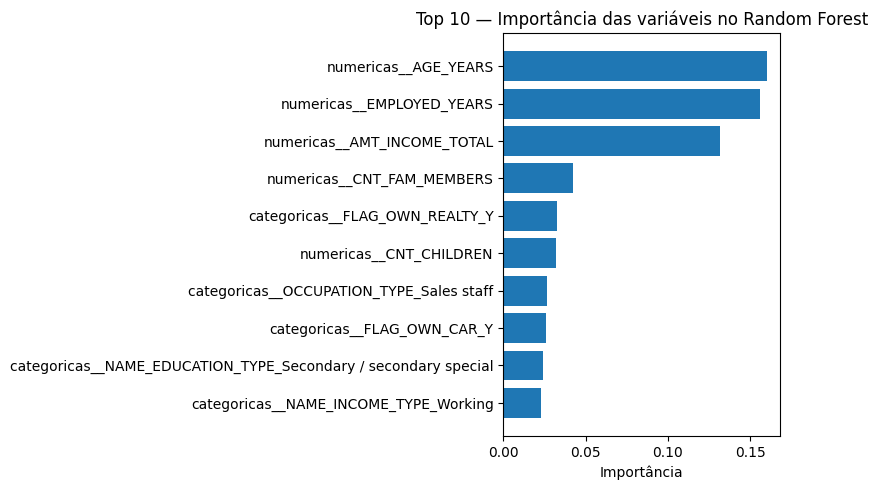

ID está entre as variáveis preditoras? False


In [15]:
rf_features = X_train.columns
rf_importance = modelo_floresta.feature_importances_

importancias = (
    pd.DataFrame({
        "feature": rf_features,
        "importance": rf_importance
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(
    importancias.head(15).style.format({
        "importance": "{:.4f}"
    })
)

top_n = importancias.head(10).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_n["feature"], top_n["importance"])
ax.set_title("Top 10 — Importância das variáveis no Random Forest")
ax.set_xlabel("Importância")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_importancia_random_forest.png", dpi=150, bbox_inches="tight")
plt.show()

print("ID está entre as variáveis preditoras?", any(importancias["feature"].str.contains("ID", regex=False)))

## 12. Diagnóstico de ajuste

A comparação entre desempenho no treino e no teste ajuda a identificar sinais de sobreajuste. Ela é complementar às métricas de classificação da classe 1.

In [16]:
diagnostico_ajuste = pd.DataFrame({
    "Modelo": ["KNN", "Regressão Logística", "Random Forest"],
    "Accuracy_treino": [
        modelo_knn.score(X_train_scaled, y_train),
        modelo_logistico.score(X_train_scaled, y_train),
        modelo_floresta.score(X_train, y_train),
    ],
    "Accuracy_teste": [
        modelo_knn.score(X_test_scaled, y_test),
        modelo_logistico.score(X_test_scaled, y_test),
        modelo_floresta.score(X_test, y_test),
    ],
})

display(
    diagnostico_ajuste.style.format({
        "Accuracy_treino": "{:.4f}",
        "Accuracy_teste": "{:.4f}",
    })
)

,Modelo,Accuracy_treino,Accuracy_teste
0,KNN,0.9875,0.9650
1,Regressão Logística,0.6195,0.6231
2,Random Forest,0.9557,0.9493


## 13. Implicações para o negócio

A decisão de crédito não deve ser baseada somente na Accuracy, pois a classe de maus pagadores é minoritária.

O modelo deve ser interpretado como **ferramenta de apoio à análise**, especialmente enquanto a capacidade discriminativa permanecer limitada. O resultado pode ajudar a priorizar análises e identificar perfis que mereçam investigação adicional, mas não justifica, isoladamente, aprovação ou recusa automática.

Também é importante avaliar posteriormente custos de falsos positivos e falsos negativos com dados reais da operação, caso estejam disponíveis.

## 14. Limitações

- Forte desbalanceamento da variável-alvo.
- A definição de `TARGET` depende da regra construída a partir do histórico de crédito.
- Perfis cadastrais repetidos e alguns perfis com TARGET conflitante exigem divisão agrupada.
- A base contém apenas as variáveis disponibilizadas para o projeto.
- Métricas próximas do nível de discriminação aleatória limitam o uso do modelo como único critério decisório.
- Não foram definidos custos financeiros específicos para FP e FN; portanto, não é possível estabelecer um limiar de decisão ótimo do ponto de vista econômico apenas com esta base.

## 15. Conclusão final

A avaliação final utiliza divisão por grupos, pré-processamento ajustado somente no treinamento e teste mantido separado da seleção do hiperparâmetro.

O modelo final é escolhido pelo maior **F1 da classe 1**, enquanto Recall e AUC são apresentados como métricas complementares. A conclusão executiva deve ser baseada nos valores efetivamente produzidos na execução deste notebook.

Após a execução, os resultados desta etapa devem ser usados como fonte única para atualizar o README e a apresentação executiva.

In [17]:
# Consolidação final
resultado_final = resultados_teste.copy()

print("=== RESULTADO FINAL ===")
display(
    resultado_final.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "AUC": "{:.4f}",
    })
)

print("Modelo selecionado:", modelo_final_nome)
print(f"Melhor F1: {melhor_f1['F1']:.4f}")
print(f"Melhor Recall: {melhor_recall['Recall']:.4f}")
print(f"Melhor AUC: {melhor_auc['AUC']:.4f}")

print("\nDivisão final:")
print("Treino:", X_train.shape[0])
print("Validação:", X_val.shape[0])
print("Teste:", X_test.shape[0])
print("Variáveis após encoding:", X_train.shape[1])

=== RESULTADO FINAL ===


,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Random Forest,0.9493,0.0452,0.0989,0.0621,0.6109
1,Regressão Logística,0.6231,0.0160,0.3516,0.0307,0.5065
2,KNN,0.9650,0.0198,0.0220,0.0208,0.5016


Modelo selecionado: Random Forest
Melhor F1: 0.0621
Melhor Recall: 0.3516
Melhor AUC: 0.6109

Divisão final:
Treino: 25743
Validação: 5347
Teste: 5367
Variáveis após encoding: 46


In [18]:
# Salva artefatos locais para documentação/etapas seguintes.
# Esses arquivos devem permanecer fora do Git conforme o .gitignore.
modelos_treinados = {
    "KNN": modelo_knn,
    "Regressão Logística": modelo_logistico,
    "Random Forest": modelo_floresta,
}

joblib.dump(modelos_treinados, PROC / "modelos_treinados.joblib")
resultado_final.to_csv(PROC / "resultados_teste_modelagem.csv", index=False)
knn_resultados.to_csv(PROC / "resultados_knn_k.csv", index=False)
importancias.to_csv(PROC / "importancia_random_forest.csv", index=False)
diagnostico_ajuste.to_csv(PROC / "diagnostico_ajuste.csv", index=False)

print("Artefatos salvos em:", PROC)
print("Figuras salvas em:", FIG_DIR)

Artefatos salvos em: c:\projetos\Grupo_50_Tech-Challenge-Fase-2\data\processed
Figuras salvas em: c:\projetos\Grupo_50_Tech-Challenge-Fase-2\docs\figuras_avaliacao
